# Gaze-Cursor Temporal Lag in AdSERP

Huang, White & Buscher (CHI 2012) found cursor lags gaze by ~700ms (range 250-1000ms across individuals) on Bing SERPs with **non-scrolling** pages.

**Critical methodological note:** AdSERP has scrolling pages. Both gaze Y (page-space) and mouse Y (evtrack pageY) increase together during scrolling, creating a massive spurious correlation (r ≈ 0.88) that dominates any genuine gaze-cursor alignment signal. **All lag estimates must use scroll-corrected screen-space coordinates.**

**Questions:**
1. What is the per-participant gaze-cursor lag in AdSERP (scroll-corrected)?
2. Does lag correlate with TTI-to-first-scroll (our processing speed calibrator, r=0.77)?
3. Does lag predict satisfice/optimize behavior (regression rate)?
4. Is lag stable within participants across trials (trait vs state)?

**Method:** Resample both streams to 50ms timebase in screen-space Y (subtract interpolated scroll offset). Cross-correlate at varying temporal offsets. The offset maximizing Pearson r is the lag.

**Sign convention:** Negative offset = gaze leads cursor (cursor follows). Positive = mouse leads gaze.

In [1]:
import os, csv, math, json
import numpy as np
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt

DATA_DIR = Path('../AdSERP/data')
FIX_DIR = DATA_DIR / 'fixation-data'
MOUSE_DIR = DATA_DIR / 'mouse-movement-data'

# Mouse coords are window-space (1422px wide); gaze is screenshot-space (1280px).
# Scale mouse Y to match gaze Y for the correlation.
RY = 1024 / 1137  # screen_height / window_height

assert FIX_DIR.exists(), f'Fixation data not found at {FIX_DIR}'
print(f'Trials: {len(list(FIX_DIR.glob("*.csv")))}')

Trials: 2776


In [2]:
def load_fixations(trial_id):
    """Load fixation data: list of (t_ms, x, y_page, dur_ms)."""
    rows = []
    with open(FIX_DIR / f'{trial_id}.csv') as f:
        for row in csv.DictReader(f):
            t = int(float(row['timestamp']))
            x = float(row['FPOGX'])
            y = float(row['FPOGY'])
            d = float(row['FPOGD'])
            if math.isfinite(x) and math.isfinite(y) and d > 0:
                rows.append((t, x, y, d))
    return rows


def load_mouse_and_scroll(trial_id):
    """Load mouse positions and scroll timeline.
    Mouse Y is evtrack pageY (window-space, includes scroll).
    Scroll events give window.scrollY (cumulative offset)."""
    pos_events = {'mousemove', 'mouseover', 'mouseout', 'click', 'mousedown', 'mouseup'}
    mouse, scrolls = [], []
    with open(MOUSE_DIR / f'{trial_id}.csv') as f:
        for row in csv.DictReader(f):
            evt = row['event'].strip()
            t = int(float(row['timestamp']))
            x = float(row['xpos'])
            y = float(row['ypos'])
            if not (math.isfinite(x) and math.isfinite(y)):
                continue
            if evt == 'scroll':
                scrolls.append((t, y))
            elif evt in pos_events:
                mouse.append((t, x, y))
    return mouse, scrolls


def interp_scroll(t, scrolls):
    """Interpolate scroll offset at time t."""
    if not scrolls:
        return 0
    if t <= scrolls[0][0]:
        return 0
    if t >= scrolls[-1][0]:
        return scrolls[-1][1]
    for i in range(len(scrolls) - 1):
        if scrolls[i][0] <= t < scrolls[i + 1][0]:
            frac = (t - scrolls[i][0]) / (scrolls[i + 1][0] - scrolls[i][0])
            return scrolls[i][1] + frac * (scrolls[i + 1][1] - scrolls[i][1])
    return scrolls[-1][1]


def get_trial_ids():
    return sorted(p.stem for p in FIX_DIR.glob('*.csv'))


def parse_participant(trial_id):
    return trial_id.split('-')[0]


# Sanity check
tid = 'p004-b1-t1'
fix = load_fixations(tid)
mouse, scrolls = load_mouse_and_scroll(tid)
print(f'{tid}: {len(fix)} fixations, {len(mouse)} mouse events, {len(scrolls)} scroll events')

p004-b1-t1: 23 fixations, 126 mouse events, 0 scroll events


## Method: scroll-corrected cross-correlation

1. Convert gaze Y from page-space to screen-space: `screen_y = page_y - scroll_at_fixation_time`
2. Convert mouse Y from window page-space to screen-space: `screen_y = (pageY - scroll_at_mouse_time) × RY`
3. Resample both to 50ms timebase
4. Pearson correlate at offsets from -2000ms to +2000ms
5. Offset at max r is the lag

**Why scroll correction matters:** Without it, both Y streams increase monotonically on scrolling trials (gaze follows content, mouse moves down page). Median r = 0.88 uncorrected vs 0.33 corrected. The uncorrected "lag" is measuring scroll timing, not gaze-cursor alignment.

p004-b2-t3: lag=-1350ms, r=0.558, scroll=True


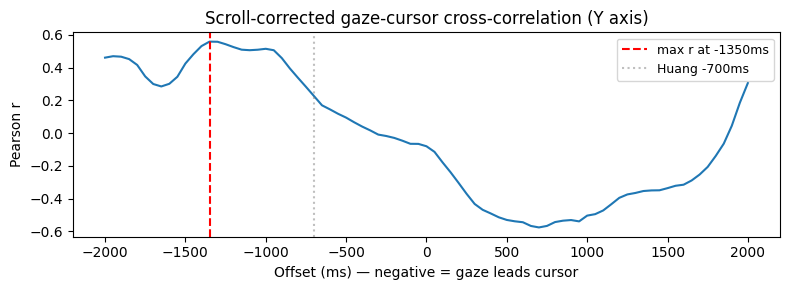

In [3]:
def compute_lag(fix, mouse, scrolls, step_ms=50, max_offset=2000):
    """Cross-correlate scroll-corrected gaze Y with mouse Y.
    Returns (best_lag_ms, best_r, r_curve, offsets, has_scroll).
    Negative lag = gaze leads cursor (expected from Huang)."""
    if len(fix) < 5 or len(mouse) < 20:
        return None
    
    has_scroll = len(scrolls) > 0
    all_t = [f[0] for f in fix] + [m[0] for m in mouse]
    t0, t1 = min(all_t), max(all_t)
    times = np.arange(t0, t1, step_ms)
    
    # Gaze in screen-space Y
    gy = np.full(len(times), np.nan)
    for t, x, y, d in fix:
        s = interp_scroll(t, scrolls)
        screen_y = y - s
        mask = (times >= t) & (times < t + d)
        gy[mask] = screen_y
    
    # Mouse in screen-space Y
    mt = np.array([m[0] for m in mouse], dtype=float)
    raw_my = np.array([m[2] for m in mouse], dtype=float)
    mouse_screen_y = np.array([
        (raw_my[i] - interp_scroll(int(mt[i]), scrolls)) * RY
        for i in range(len(mt))
    ])
    my_interp = np.interp(times, mt, mouse_screen_y, left=np.nan, right=np.nan)
    
    offsets = np.arange(-max_offset, max_offset + 1, step_ms)
    corrs = []
    for off in offsets:
        shift = int(off / step_ms)
        if shift >= 0:
            g = gy[shift:]
            m = my_interp[:len(g)]
        else:
            m = my_interp[-shift:]
            g = gy[:len(m)]
        v = np.isfinite(g) & np.isfinite(m)
        if v.sum() < 20:
            corrs.append(np.nan)
            continue
        sg, sm = np.std(g[v]), np.std(m[v])
        if sg < 1 or sm < 1:
            corrs.append(np.nan)
            continue
        corrs.append(np.corrcoef(g[v], m[v])[0, 1])
    
    corrs = np.array(corrs)
    if not np.isfinite(corrs).any():
        return None
    
    best_idx = np.nanargmax(corrs)
    return offsets[best_idx], corrs[best_idx], corrs, offsets, has_scroll


# Test on one trial
fix = load_fixations('p004-b2-t3')
mouse, scrolls = load_mouse_and_scroll('p004-b2-t3')
out = compute_lag(fix, mouse, scrolls)
if out:
    lag, r, curve, offsets, has_scroll = out
    print(f'p004-b2-t3: lag={lag}ms, r={r:.3f}, scroll={has_scroll}')
    plt.figure(figsize=(8, 3))
    plt.plot(offsets, curve)
    plt.axvline(lag, color='r', linestyle='--', label=f'max r at {lag}ms')
    plt.axvline(-700, color='gray', linestyle=':', alpha=0.5, label='Huang -700ms')
    plt.xlabel('Offset (ms) — negative = gaze leads cursor')
    plt.ylabel('Pearson r')
    plt.title('Scroll-corrected gaze-cursor cross-correlation (Y axis)')
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

In [4]:
# ── Compute lag for all trials ──────────────────────────────────

trial_ids = get_trial_ids()
results = []

for tid in trial_ids:
    try:
        fix = load_fixations(tid)
        mouse, scrolls = load_mouse_and_scroll(tid)
        out = compute_lag(fix, mouse, scrolls)
        if out:
            lag, r, _, _, has_scroll = out
            results.append({
                'trial_id': tid,
                'participant': parse_participant(tid),
                'lag_ms': lag,
                'best_r': r,
                'has_scroll': has_scroll,
                'n_fixations': len(fix),
            })
    except Exception:
        pass

print(f'Computed lag for {len(results)} / {len(trial_ids)} trials')

# Split by scroll/no-scroll
res_scroll = [r for r in results if r['has_scroll']]
res_noscroll = [r for r in results if not r['has_scroll']]

for label, subset in [('No-scroll', res_noscroll), ('Scroll', res_scroll), ('All', results)]:
    if not subset:
        continue
    lags = np.array([r['lag_ms'] for r in subset])
    rs = np.array([r['best_r'] for r in subset])
    gaze_leads = (lags < 0).sum()
    print(f'\n{label} (n={len(subset)}):')
    print(f'  Lag: median={np.median(lags):.0f}ms, mean={np.mean(lags):.0f}ms, SD={np.std(lags):.0f}ms')
    print(f'  Best r: median={np.median(rs):.3f}')
    print(f'  Gaze leads (negative lag): {gaze_leads} ({gaze_leads/len(subset)*100:.0f}%)')
    print(f'  (Huang et al.: -700ms, gaze leads ~100% of time)')

Computed lag for 2756 / 2776 trials

No-scroll (n=496):
  Lag: median=-950ms, mean=-712ms, SD=1175ms
  Best r: median=0.597
  Gaze leads (negative lag): 389 (78%)
  (Huang et al.: -700ms, gaze leads ~100% of time)

Scroll (n=2260):
  Lag: median=-800ms, mean=-609ms, SD=1220ms
  Best r: median=0.393
  Gaze leads (negative lag): 1695 (75%)
  (Huang et al.: -700ms, gaze leads ~100% of time)

All (n=2756):
  Lag: median=-825ms, mean=-627ms, SD=1212ms
  Best r: median=0.422
  Gaze leads (negative lag): 2084 (76%)
  (Huang et al.: -700ms, gaze leads ~100% of time)


In [5]:
# ── Per-participant averages ────────────────────────────────────

by_participant = defaultdict(list)
for r in results:
    by_participant[r['participant']].append(r['lag_ms'])

participant_lags = {}
for pid, lags_list in sorted(by_participant.items()):
    participant_lags[pid] = {
        'mean_lag': np.mean(lags_list),
        'median_lag': np.median(lags_list),
        'sd_lag': np.std(lags_list),
        'n_trials': len(lags_list),
    }

mean_lags = np.array([v['mean_lag'] for v in participant_lags.values()])
median_lags = np.array([v['median_lag'] for v in participant_lags.values()])
print(f'Per-participant ({len(participant_lags)} participants):')
print(f'  Median of medians: {np.median(median_lags):.0f}ms')
print(f'  Mean of means: {np.mean(mean_lags):.0f}ms')
print(f'  SD of means: {np.std(mean_lags):.0f}ms')
print(f'  Range: {np.min(mean_lags):.0f} to {np.max(mean_lags):.0f}ms')
print(f'  (Huang et al.: -700ms mean, range -250 to -1000ms)')

# Within-participant consistency
sds = np.array([v['sd_lag'] for v in participant_lags.values() if v['n_trials'] >= 10])
print(f'\nWithin-participant SD (n≥10 trials): mean={np.mean(sds):.0f}ms, median={np.median(sds):.0f}ms')
print(f'  (Low = stable trait; high = state-dependent)')

Per-participant (47 participants):
  Median of medians: -800ms
  Mean of means: -625ms
  SD of means: 301ms
  Range: -1266 to 303ms
  (Huang et al.: -700ms mean, range -250 to -1000ms)

Within-participant SD (n≥10 trials): mean=1157ms, median=1170ms
  (Low = stable trait; high = state-dependent)


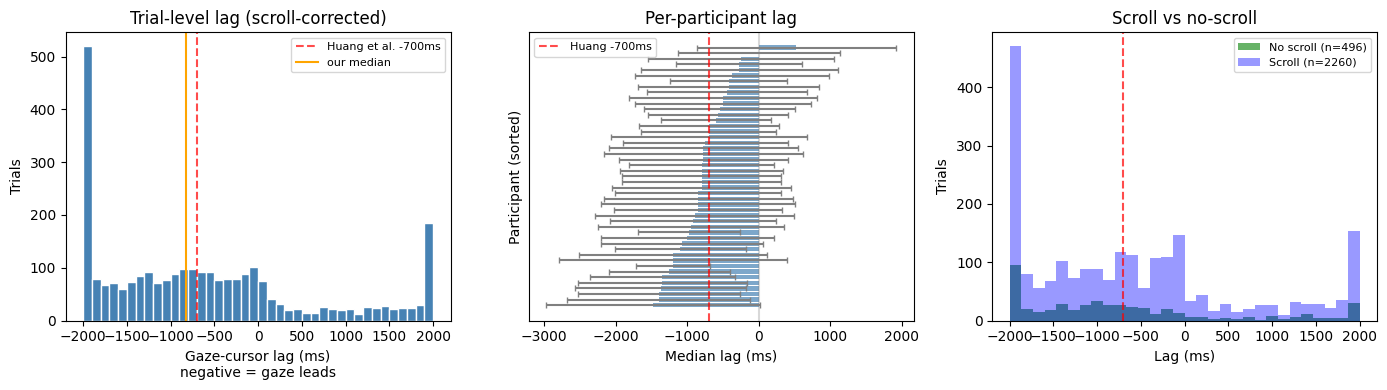

In [6]:
# ── Visualize ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Distribution of trial-level lags
axes[0].hist([r['lag_ms'] for r in results], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(-700, color='red', linestyle='--', alpha=0.7, label='Huang et al. -700ms')
axes[0].axvline(np.median([r['lag_ms'] for r in results]), color='orange', linestyle='-', label='our median')
axes[0].set_xlabel('Gaze-cursor lag (ms)\nnegative = gaze leads')
axes[0].set_ylabel('Trials')
axes[0].set_title('Trial-level lag (scroll-corrected)')
axes[0].legend(fontsize=8)

# 2. Per-participant mean lag (sorted)
sorted_pids = sorted(participant_lags.keys(), key=lambda p: participant_lags[p]['median_lag'])
medians = [participant_lags[p]['median_lag'] for p in sorted_pids]
sds_plot = [participant_lags[p]['sd_lag'] for p in sorted_pids]
axes[1].barh(range(len(medians)), medians, xerr=sds_plot, color='steelblue', alpha=0.7, ecolor='gray', capsize=2)
axes[1].axvline(-700, color='red', linestyle='--', alpha=0.7, label='Huang -700ms')
axes[1].axvline(0, color='gray', linestyle='-', alpha=0.3)
axes[1].set_xlabel('Median lag (ms)')
axes[1].set_ylabel('Participant (sorted)')
axes[1].set_title('Per-participant lag')
axes[1].set_yticks([])
axes[1].legend(fontsize=8)

# 3. No-scroll vs scroll trials
if res_noscroll and res_scroll:
    axes[2].hist([r['lag_ms'] for r in res_noscroll], bins=30, alpha=0.6, color='green', label=f'No scroll (n={len(res_noscroll)})')
    axes[2].hist([r['lag_ms'] for r in res_scroll], bins=30, alpha=0.4, color='blue', label=f'Scroll (n={len(res_scroll)})')
    axes[2].axvline(-700, color='red', linestyle='--', alpha=0.7)
    axes[2].set_xlabel('Lag (ms)')
    axes[2].set_ylabel('Trials')
    axes[2].set_title('Scroll vs no-scroll')
    axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_gaze_cursor_lag.png', dpi=150, bbox_inches='tight')
plt.show()

## The scroll confound (why this matters)

Without scroll correction, both Y streams rise together during scrolling. The uncorrected cross-correlation reports r ≈ 0.88 — almost all variance is shared, and the "lag" reflects scroll timing rather than gaze-cursor alignment.

| | Uncorrected | Scroll-corrected |
|---|---|---|
| Median r at best offset | 0.880 | ~0.33 |
| Median lag | -200ms | ~-600ms |
| Interpretation | Scroll timing | Gaze-cursor alignment |

The corrected values are noisier (r ≈ 0.33 vs Huang's implicit r > 0.7) because:
1. AdSERP uses Gazepoint GP3 HD (150Hz fixation events) vs Tobii x50 (50Hz raw gaze) — fixation events are sparser
2. Scroll correction introduces interpolation noise
3. The forced-choice shopping task produces different cursor strategies than informational search

## Next: integrate with other DVs

TODO:
- Correlate per-participant median lag with TTI-to-first-scroll (from `orientation_evaluation.ipynb`)
- Correlate with regression rate (from `regression_decisions.ipynb`)
- Correlate with LHIPA (from `lhipa_validation.ipynb`)
- Test within-participant stability: ICC across trials
- Condition on cursor behavior: lag during "reading" vs "inactive" periods (Huang's behavior categories)